In [2]:
header = "D:/K_sunada/result/CDY148/"

## 9/14 fogi calibration - CL5R

In [3]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit

In [4]:
import sklearn
from sklearn.decomposition import PCA

In [5]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [6]:
fogi = "/2023-09-14/2023-09-14T160419_ec86122f-td_fogi_frequency_sweep"
dd_fogi = datadict_from_hdf5(header + fogi +"/data")


In [7]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [8]:
Fogi = dd_fogi['s11']['values']
#imag_ge = Rabi_ge.imag
Fogi_freq = dd_fogi['fogi_freq']['values']

I = (Fogi.real)
Q = (Fogi.imag)

PCAfogi = PCA_transform(I, Q)

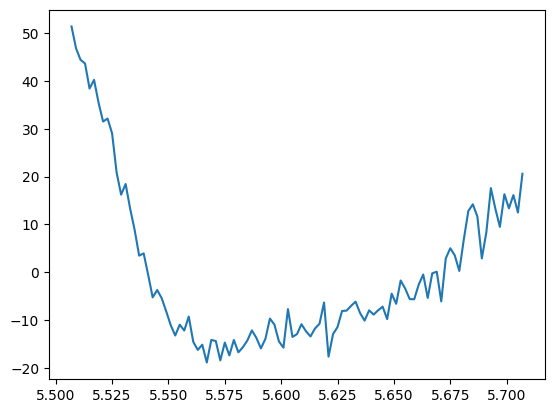

In [9]:
y = PCAfogi[0]
x = Fogi_freq

plt.plot(x, y)
plt.show()

In [10]:
par_ini = {
    'amp': 70,
    'const':-20,
    'center':5.56,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [11]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [12]:
result = model.fit(data = y, params=params, freq = x)
result

## ac stark shift

In [13]:
ac = "/2023-09-19/2023-09-19T220752_8a75fe7e-td_fogi_ac_Stark_shift"
dd_ac = datadict_from_hdf5(header + ac +"/data")

xs = []
ys = []

for i in range(11):
    ini = 101*i
    fin = 101*(1+i)
    x = dd_ac['fogi_freq']['values'][ini:fin]
    y = dd_ac['s11']['values'][ini:fin].imag
    xs.append(x)
    ys.append(y)

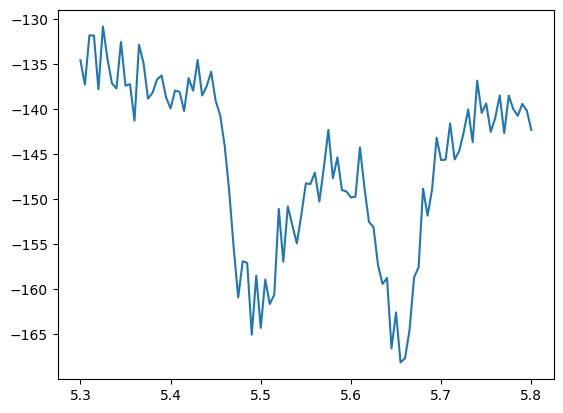

In [14]:
plt.plot(xs[0], -ys[0])
plt.show()

In [15]:
par_ini = {
    'amp': 30,
    'const':-135,
    'center':5.55,
    'k':0.025
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [16]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [17]:
results = []
for i in range(10):
    result = model.fit(data = -ys[i], params=params, freq = xs[i])
    results.append(result)

In [18]:
results[9]

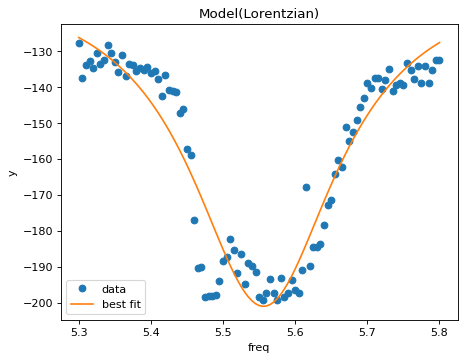

In [19]:
fig, ax = plt.subplots(dpi=80)
results[9].plot_fit(ax = ax)
plt.show()

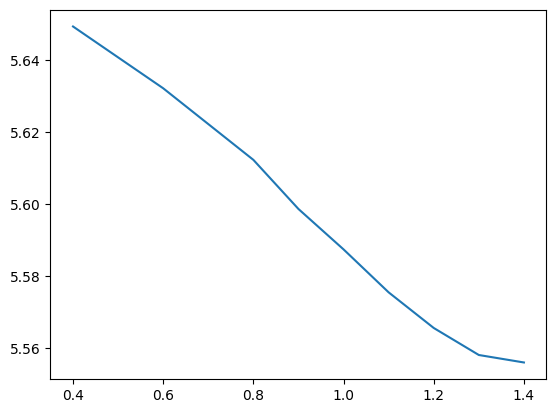

In [20]:
x =[0.4, 0.6 , 0.8, 0.9, 1.0, 1.1, 1.2, 1.3, 1.4]
y =[5.64943563, 5.63226384, 5.61237664, 5.59872679, 5.58750235, 5.57556740, 
    5.56567195,5.55816482, 5.55608781]

plt.plot(x, y)
plt.show()

In [21]:
def ac_stark(amp, const, alpha):
    return const - alpha*(amp**2)

In [22]:
par_ini = {
    'const':5.64,
    'alpha':0.11
}

par_min = {
    'const':0,
    'alpha':0
}

par_max = {
    'const':np.inf,
    'alpha':np.inf
}

par_vary = {
    'const':True,
    'alpha':True
}

In [23]:
model = lmfit.Model(ac_stark)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [24]:
result = model.fit(data = y, params=params, amp = x)
result

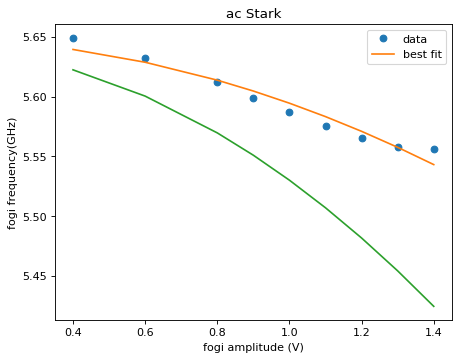

In [25]:
fig, ax = plt.subplots(dpi=80)

plt.title("ac Stark")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(x ,result.init_fit)

plt.xlabel("fogi amplitude (V)")
plt.ylabel("fogi frequency(GHz)")


plt.show()

fogi duration

In [28]:
fogi_duration = "/2023-09-14/2023-09-14T161246_1ad1f5bc-td_fogi_time_sweep"
dd_fogi_duration = datadict_from_hdf5(header + fogi_duration +"/data")

In [36]:
x_duration = dd_fogi_duration['fogi_duration']['values']
y_duration = dd_fogi_duration['s11']['values'].imag

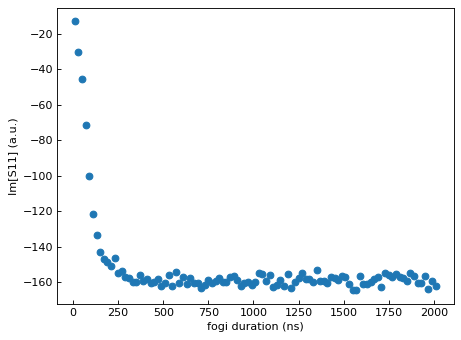

In [43]:
fig, ax = plt.subplots(dpi=80)

#plt.title("fogi duration")

plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.scatter(x_duration ,y_duration)

plt.xlabel("fogi duration (ns)")
plt.ylabel("Im[S11] (a.u.)")


plt.show()